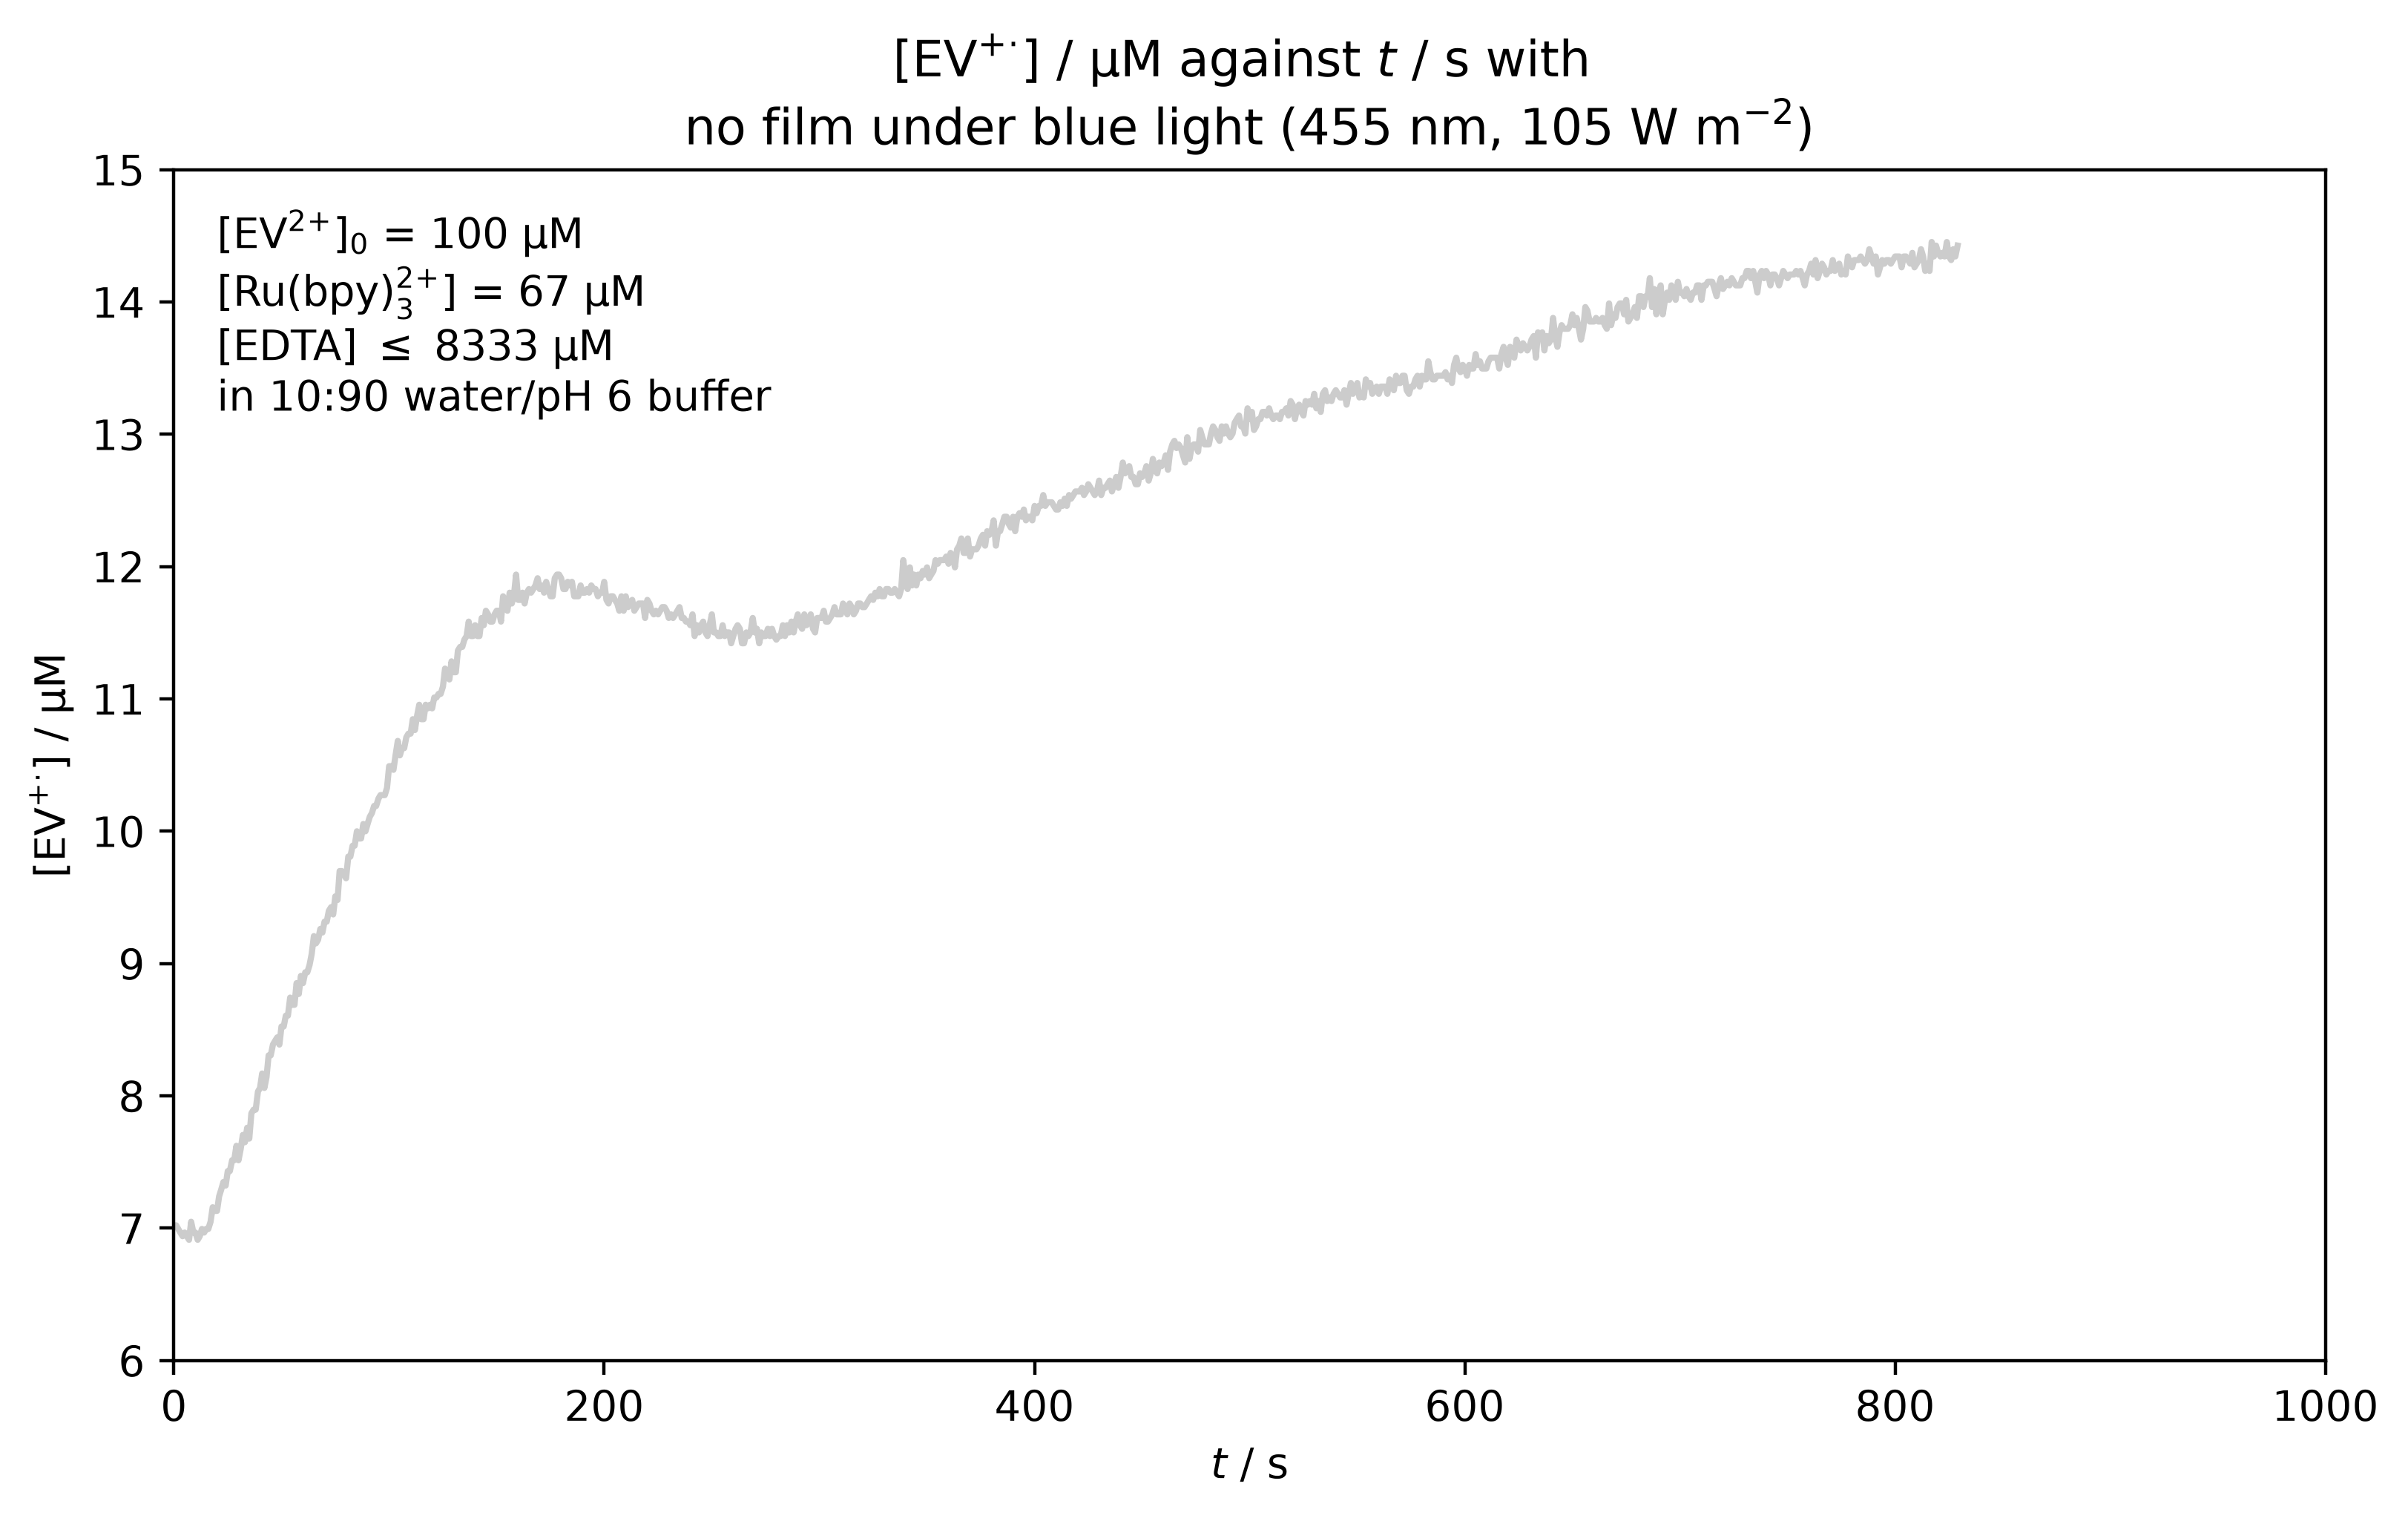

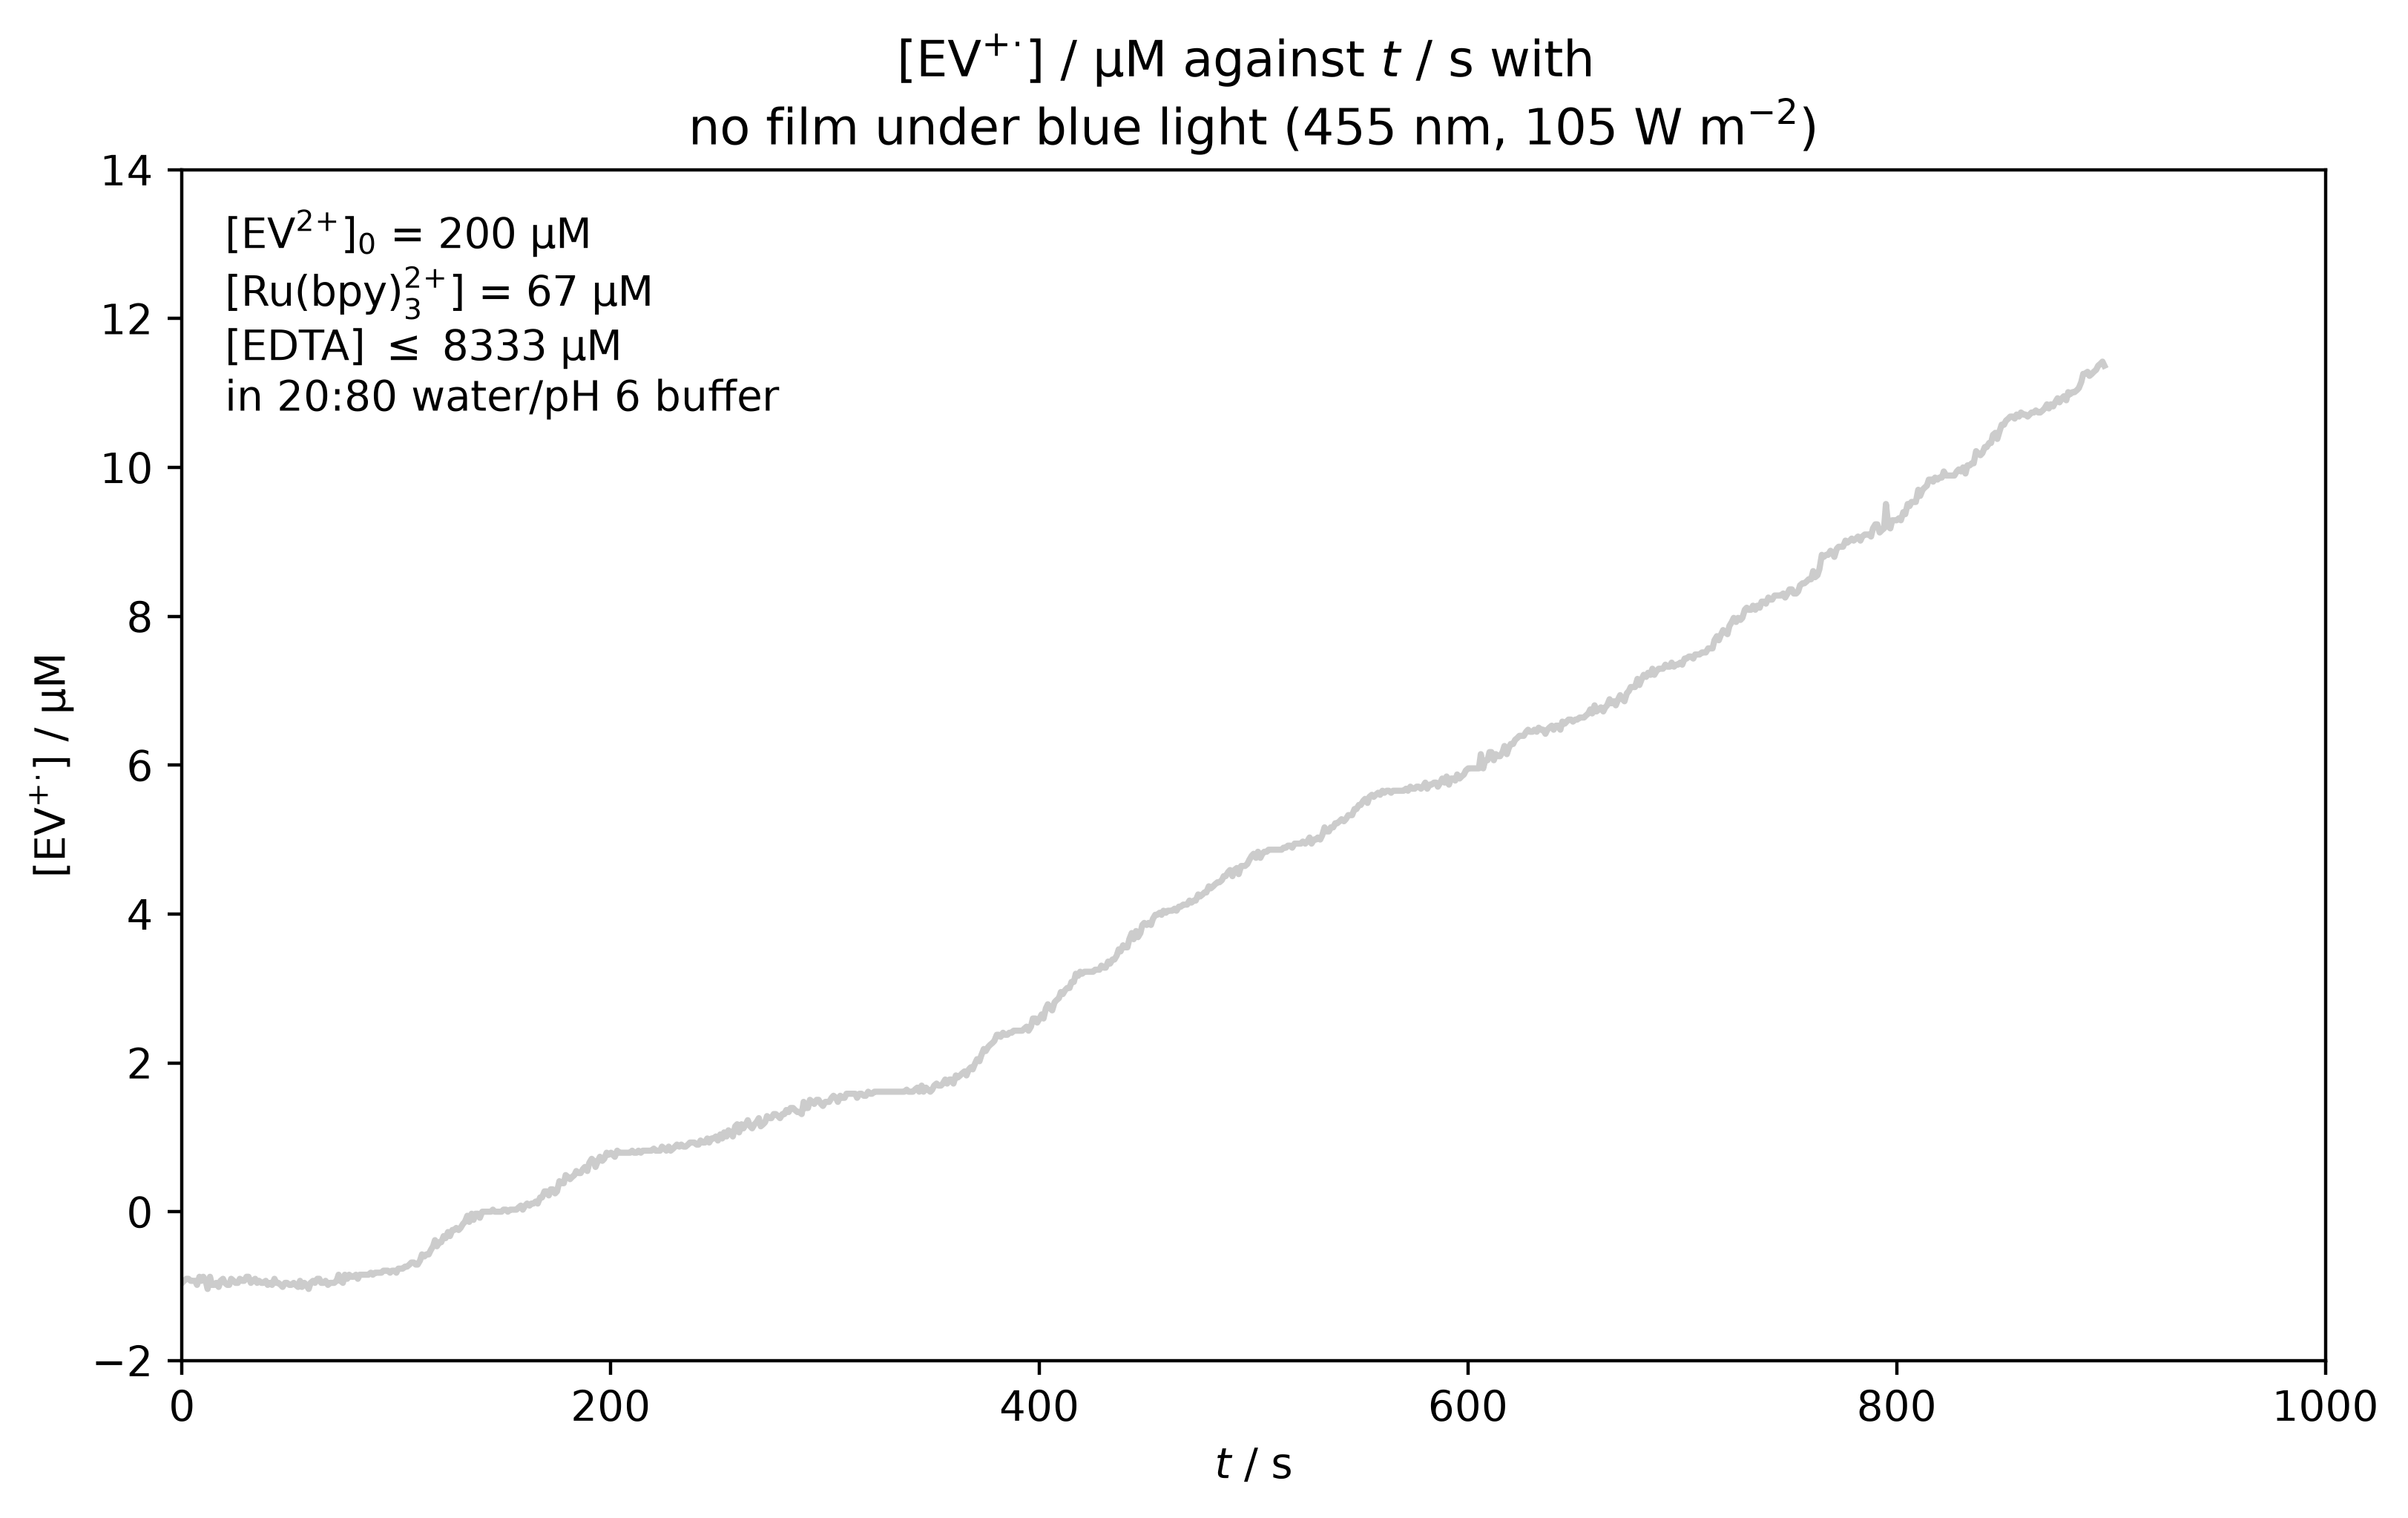

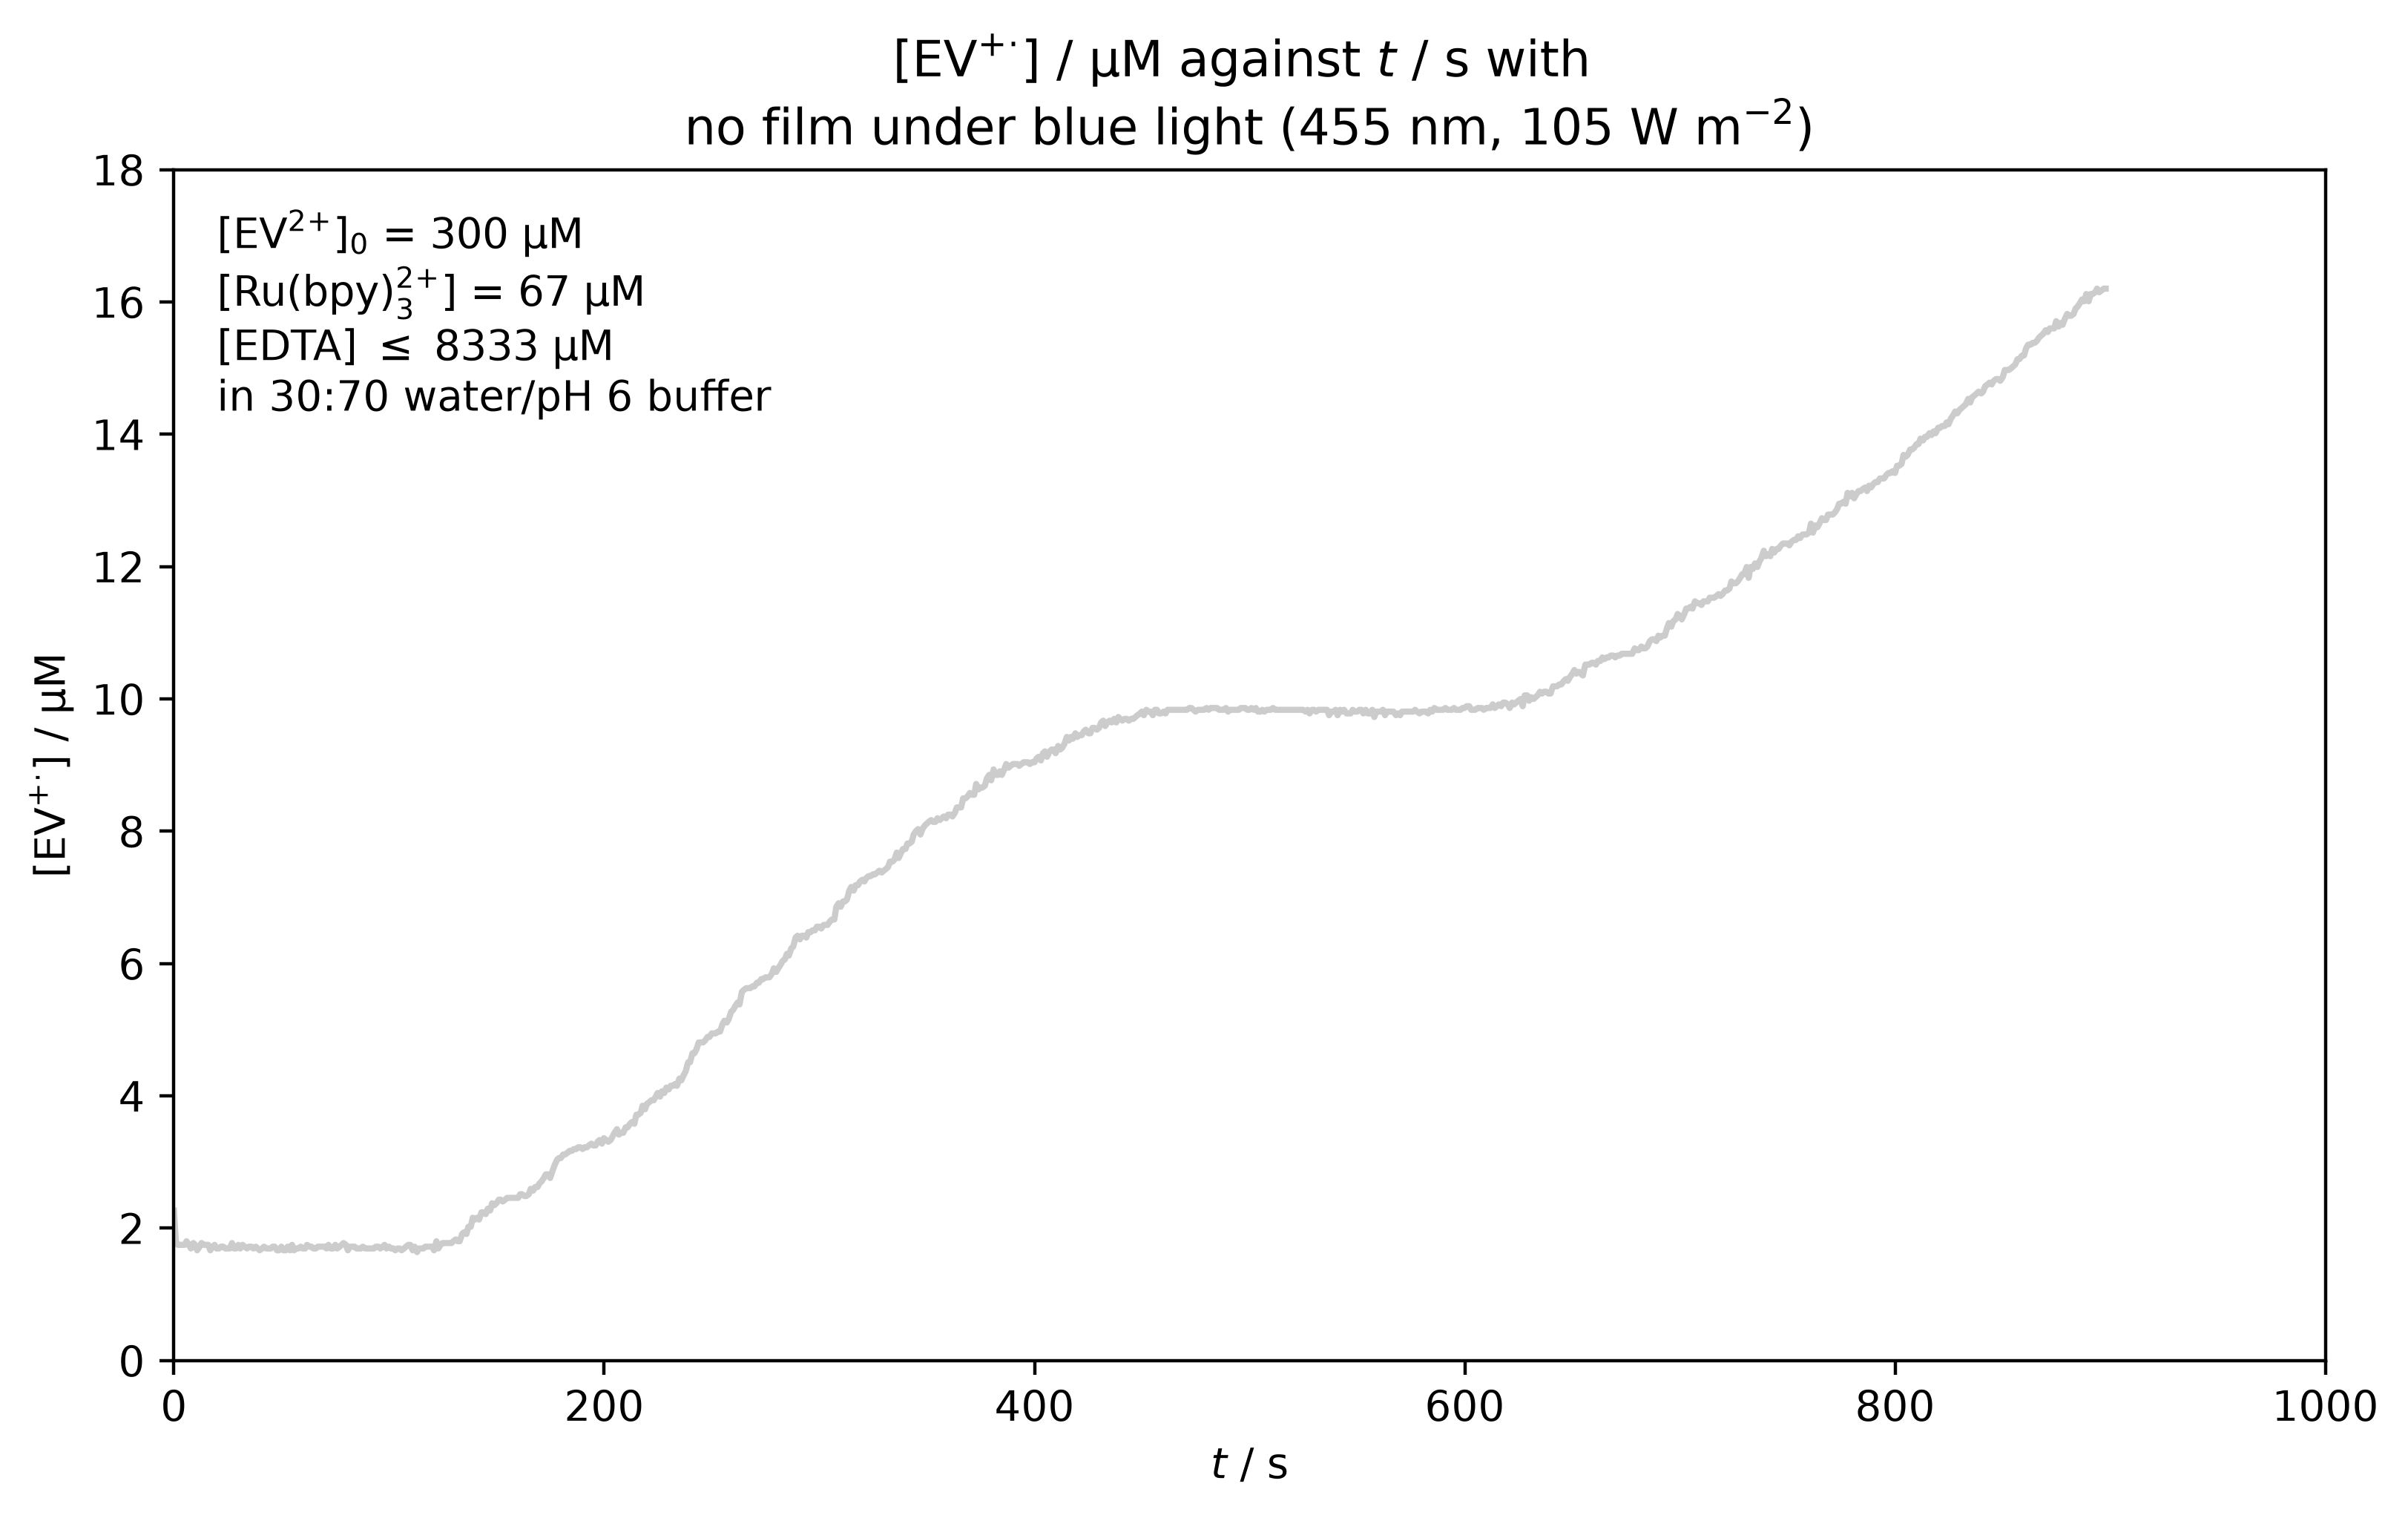

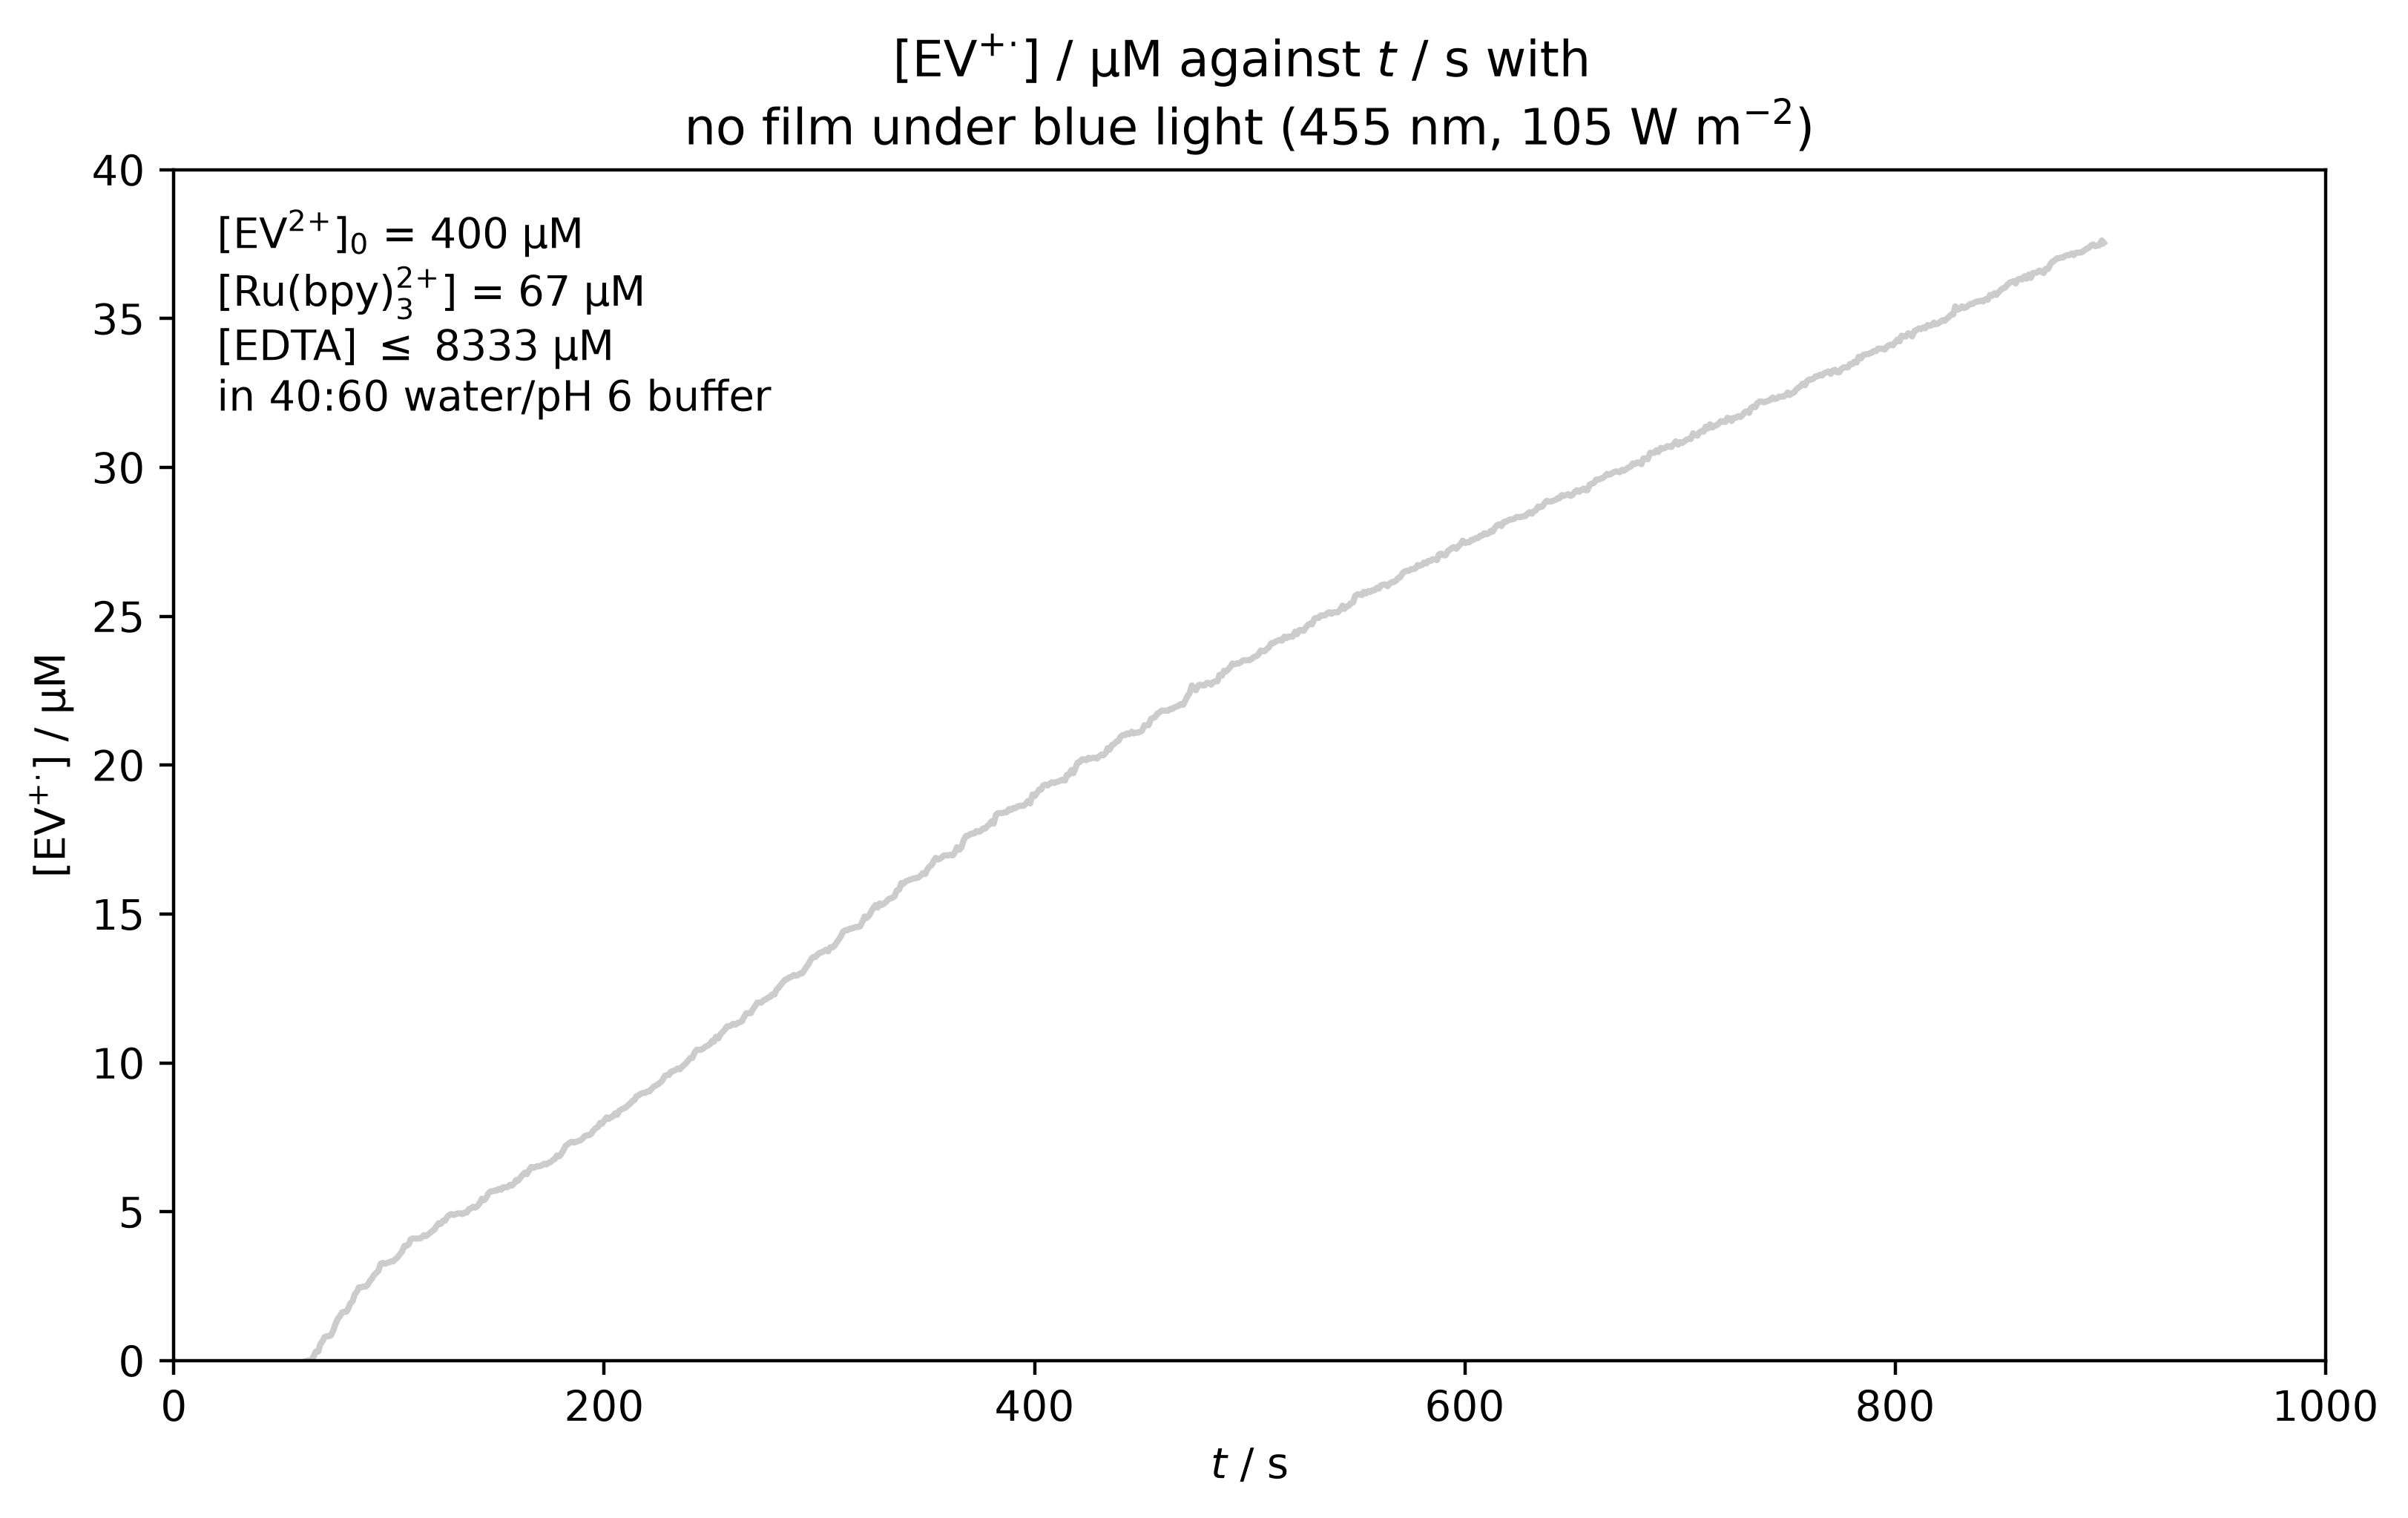

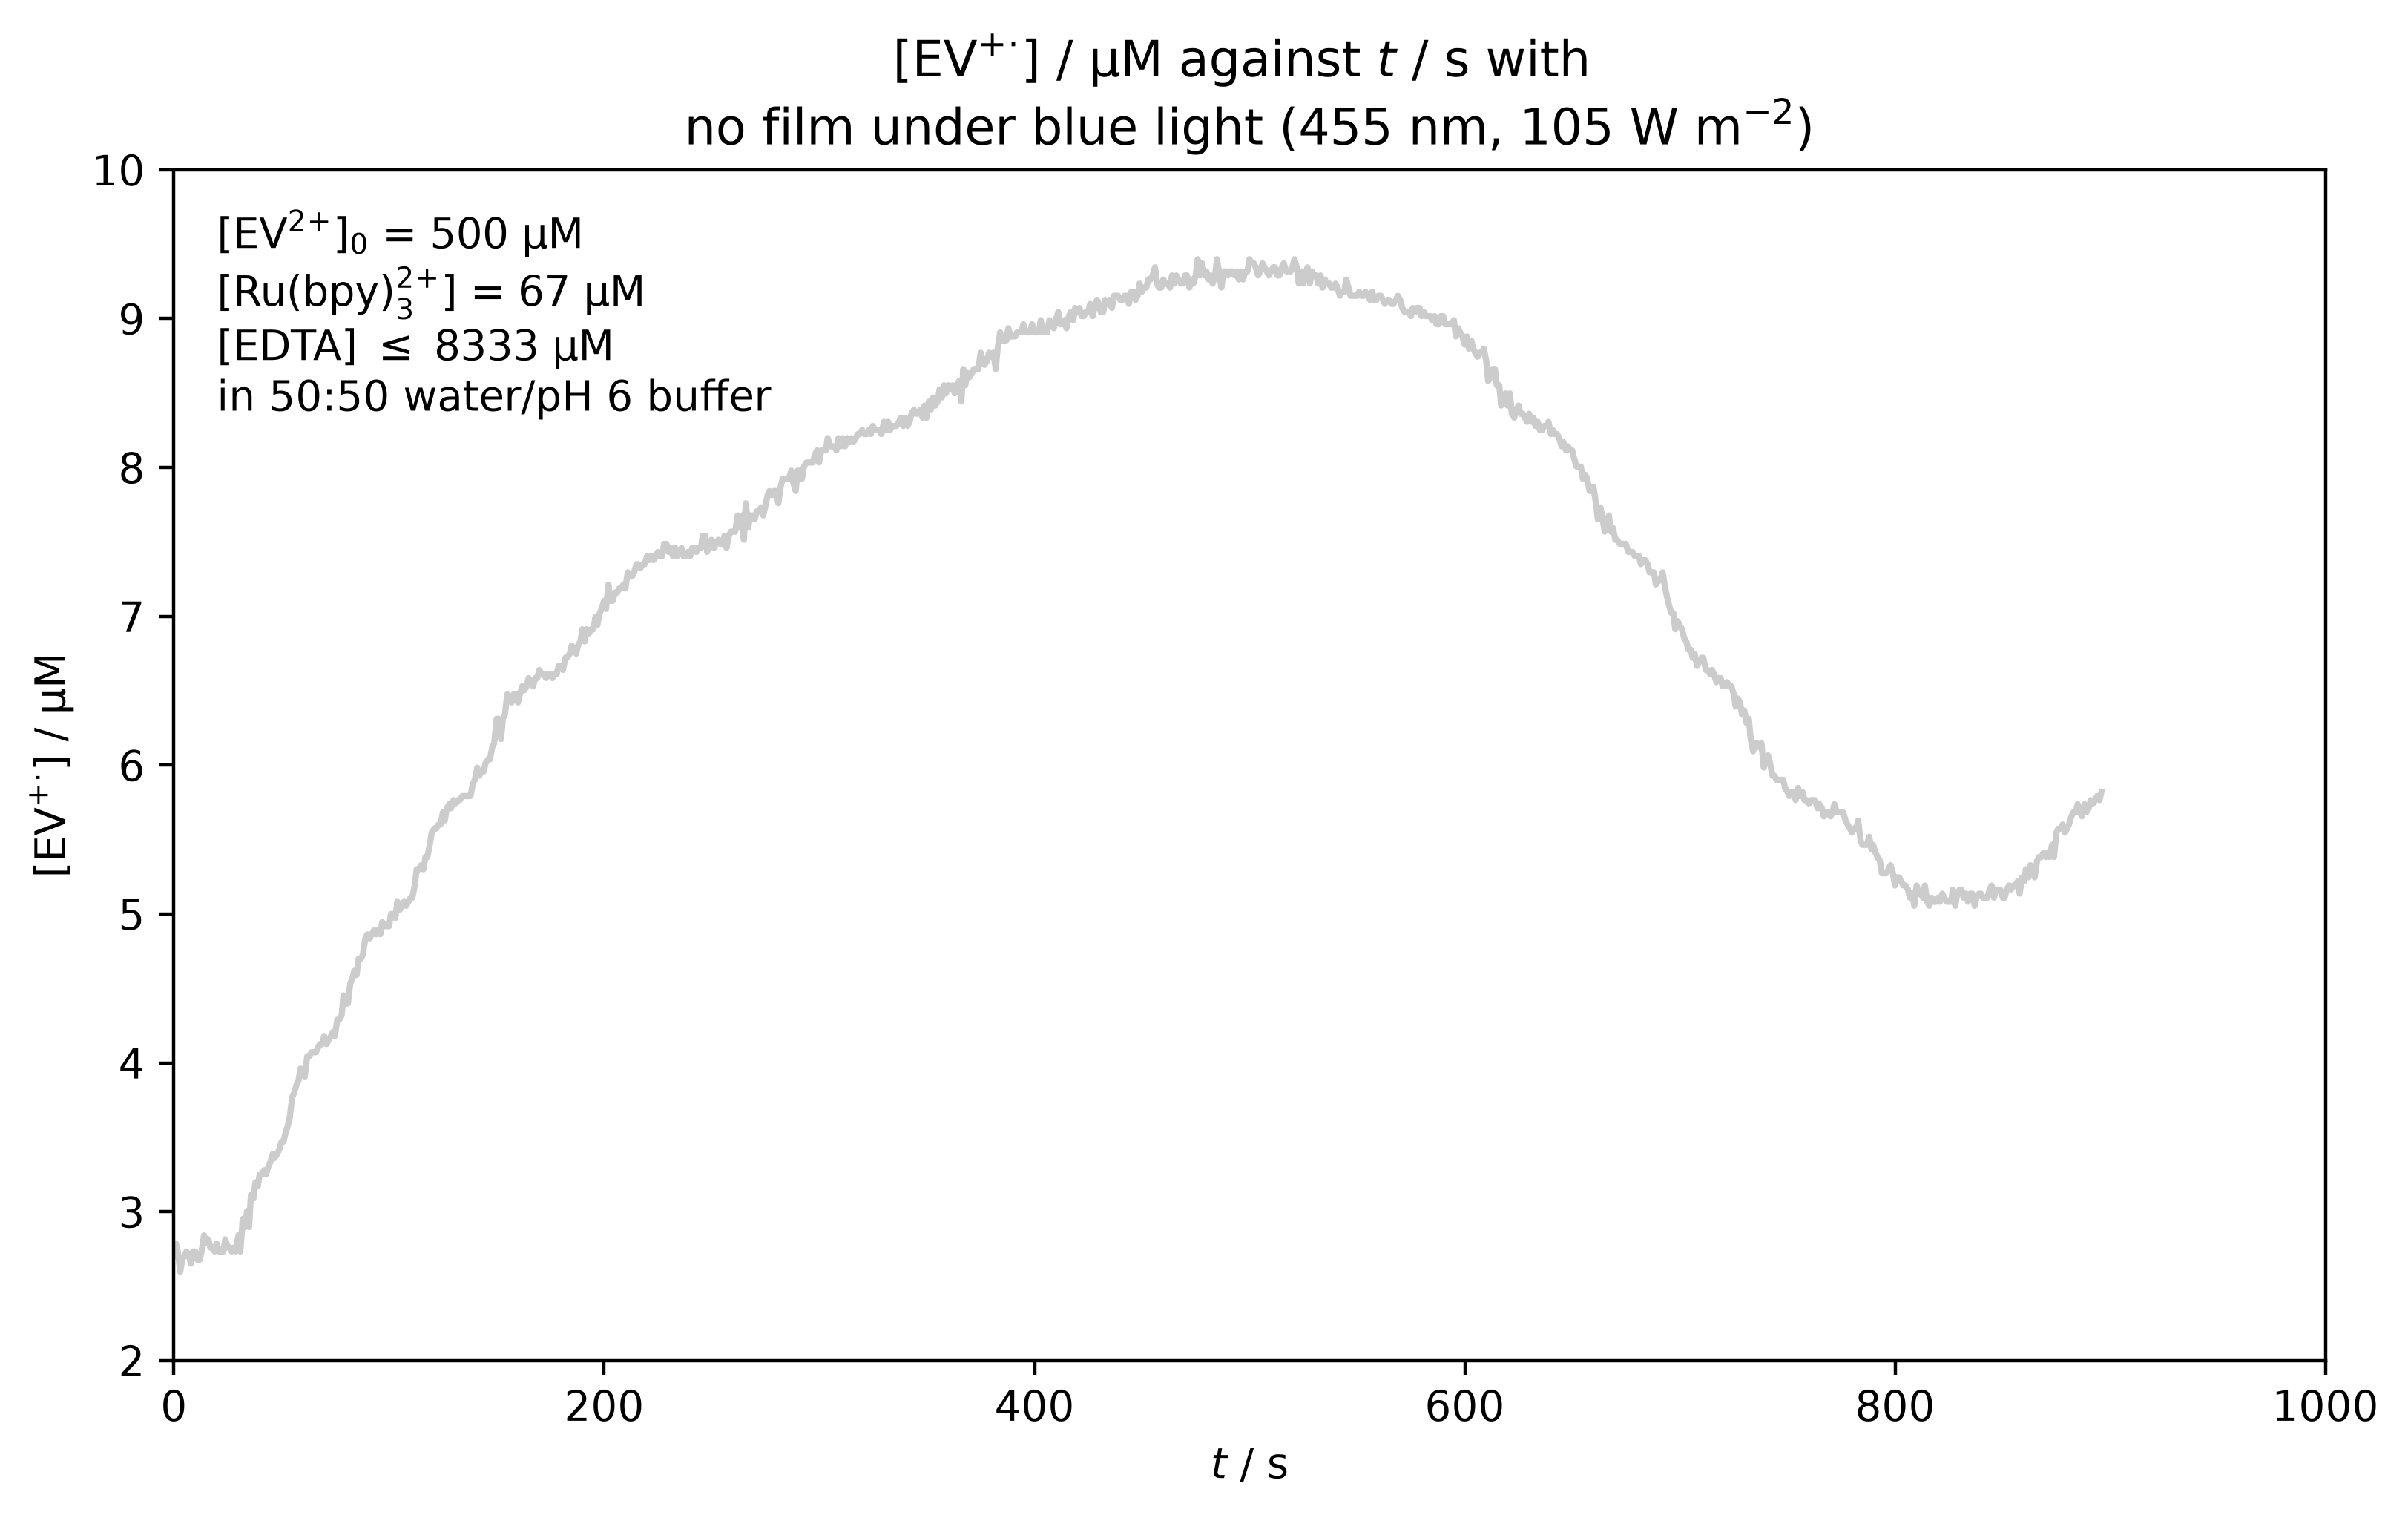

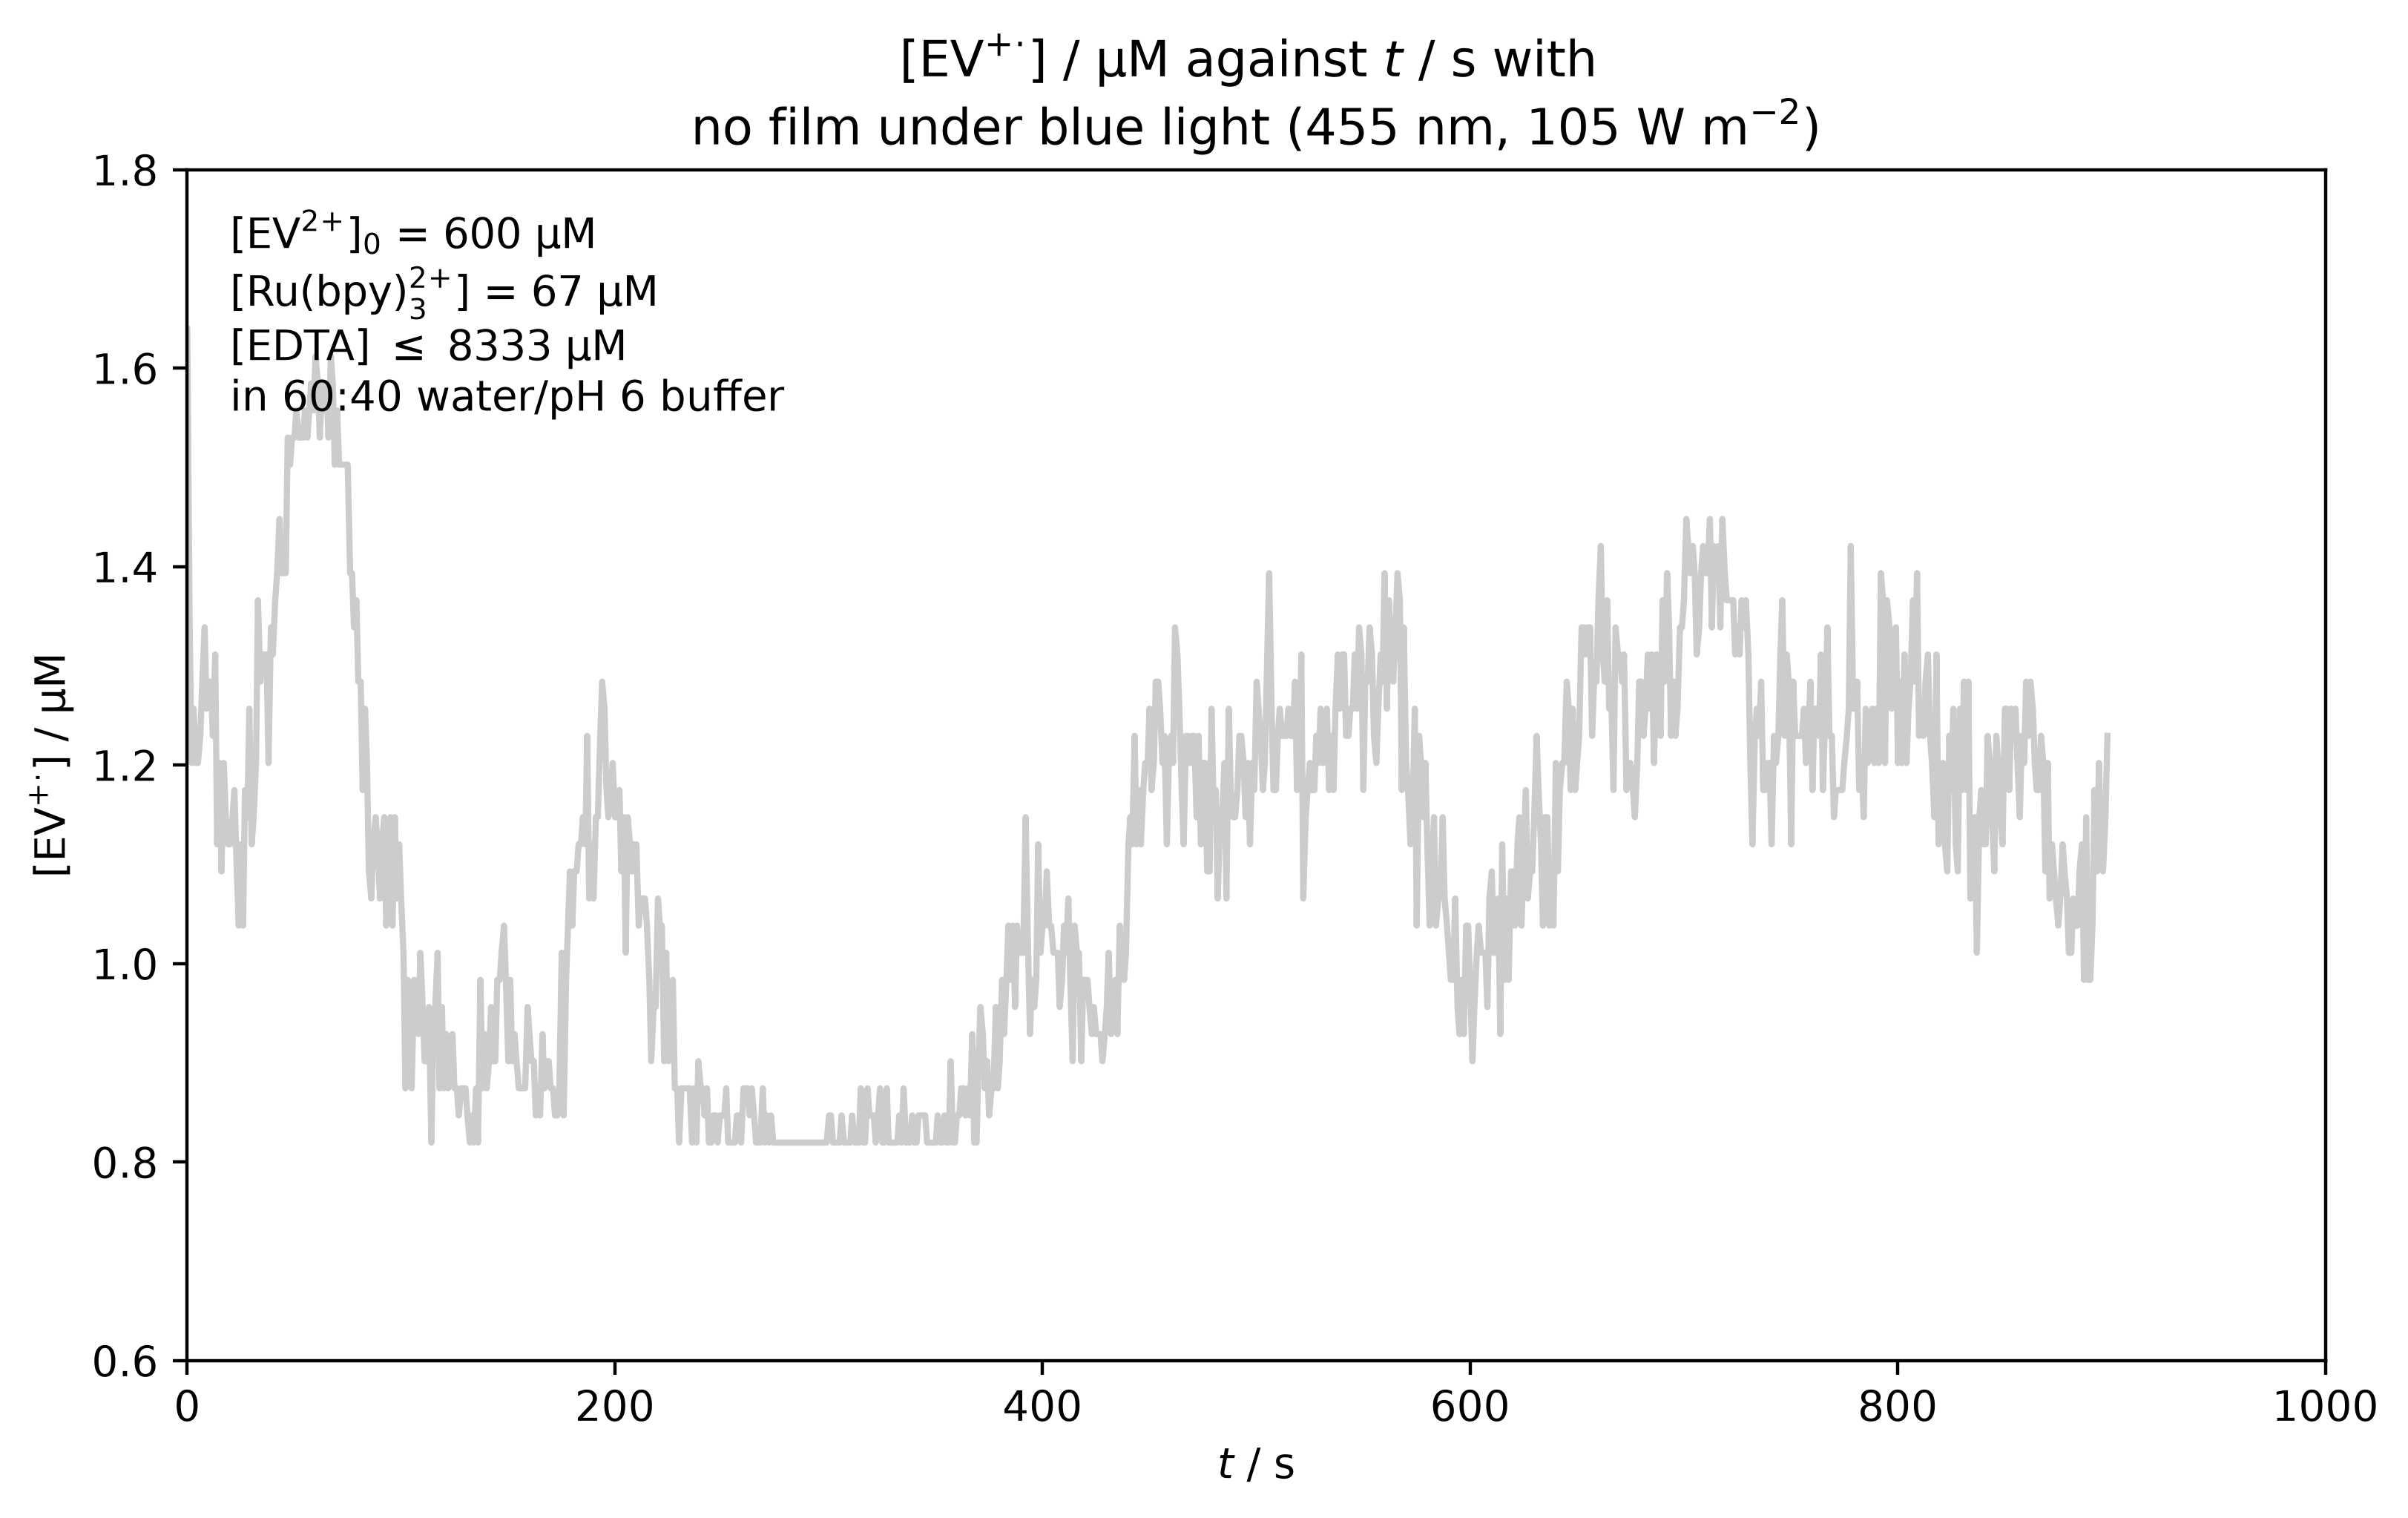

In [1]:
from lsmr_photocatalysis import Batch, X

"""
Batch reaction in the lightbox with blue 455 nm irradiation.
EV2+ and [Ru(bpy)3]2+ stock solutions were in water, affected buffering capacity of solution and EDTA equilibria.
Mixing limitations in cuvette, colour gradient seen.

V([Ru(bpy)3]2+, 1 mM, water) = 200 ul (67 uM),
V(EV2+, 1 mM, water) = 300-1800 ul (100-600 uM),
V(EDTA, saturated <25 mM, pH 6 buffer) = 1 ml (<8333 uM),
Made up to 3 ml with pH 6 buffer.
"""

x = 'EVrubpybatch'
duration = 15*60 # plot up to 15 min
t = 5*60 # see spectrum at 5 min

# (V(EV2+, 1 mM, water) in ul used, start times) for each run, start time adjusted slightly to begin at linear region
runs = [(300, '16-41-38-018'), # run on 260625
        (600, '11-51-44-531'), # run on 260629
        (900, '12-19-37-068'),
        (1200, '12-43-40-656'),
        (1500, '13-05-49-986'),
        (1800, '13-27-18-002')]

for (v, start) in runs:
    data = f'260625_Rubpy_EV_EDTA/Rubpy_EV_{v}_EDTA' # data folder name
    c0 = 1e-3*(v*1e-6)/3e-3 # initial EV2+ concentration (1 mM stock) x (v ul aliquot) / (3 ml cuvette)
    details = f'{X['RU']} = 67 μM\n[EDTA] $\\leq$ 8333 μM\nin {v*100/3000:.0f}:{100-v*100/3000:.0f} water/pH 6 buffer' # concentrations of reagents
    expt = Batch(data, start, c0, details, x, correction=False, duration=duration)
    expt.concvstimeplot(linreg=False)